# Inteligencia Artificial (FP13) — **Tarea de la Unidad 3**
## 3.4 Segregación de datos · 3.5 Modelo de entrenamiento
### 🔑 **VERSIÓN RESUELTA (docente)**

**Universidad Autónoma de Guadalajara** · Ingeniería Biomédica

---

> **Caso:** Servicio de Urgencias. Predecir si un paciente **ingresará a la Unidad de Cuidados
> Intensivos (UCI) dentro de las primeras 24 h** a partir de los signos vitales y laboratorios
> tomados en la **primera hora** de su llegada.

**Lo que la tarea evalúa**

1. Ingerir y consolidar dos fuentes en formatos distintos (arrastre de 3.2).
2. Aplicar la limpieza mínima indispensable antes de segregar (arrastre de 3.3).
3. Segregar con los **dos enfoques** del libro y justificar la **estratificación**.
4. Reconocer la **fragilidad de una sola división** y el papel de `random_state`.
5. Diagnosticar **sobreajuste** comparando el desempeño en entrenamiento contra el de datos no vistos.
6. Estimar el desempeño con **validación cruzada estratificada** y reportar `media ± desv. estándar`.

**Fuera de alcance (Unidad 4):** escalamiento, ingeniería de características y codificación one-hot.
Por eso el dataset se eligió **sin variables categóricas de más de dos niveles** y solo se aplica
un **mapeo** de `sexo` a 0/1, técnica que ya se vio en 3.3.

---

### Nota sobre los datos

Los dos archivos son **datos sintéticos**, generados con semilla fija a partir de rangos clínicos
plausibles (frecuencia cardiaca, PAS, FR, temperatura, SpO₂, lactato, creatinina, leucocitos).
**No corresponden a pacientes reales** y no deben usarse para ninguna conclusión clínica. Se
construyeron así para poder controlar el desbalance de clases, los faltantes y los duplicados que
la tarea necesita ejercitar.

## Solucionario — claves de calificación

| Bloque | Qué se busca | Puntos |
|---|---|---|
| 1. Ingesta y consolidación | Usa `na_values='ND'`; detecta 747 filas, 32 duplicados y 48 faltantes | 20 |
| 2. Limpieza mínima | Imputa por mediana, elimina duplicados, **baraja**, mapea `sexo` | — |
| 3. Problema, X/y y línea base | Excluye `id_paciente`; reporta ~21 % de positivos y el 79 % del modelo trivial | 15 |
| 4. Enfoque (1) y estratificación | Muestra que sin `stratify` la proporción de la prueba oscila | 15 |
| 5. Fragilidad de la semilla | Reporta el rango de accuracy entre semillas (~4 pp) | 10 |
| 6. Enfoque (2) | Decide en **validación**, abre la prueba **una sola vez** | 15 |
| 7. Sobreajuste | Detecta el árbol sin límite: 1.0000 en entrenamiento, mucho menos fuera | 15 |
| 8. Validación cruzada | Reporta `media ± desv.` y compara K = 5 contra K = 10 | 10 |
| Reflexión escrita | Argumenta, no describe | 10 |
| | **Total** | **100** |

> **Errores frecuentes que conviene marcar en rojo**
> 1. Olvidar `na_values='ND'` → `lactato` queda como texto y `describe()` la ignora.
> 2. Dejar `id_paciente` dentro de `X` → error de tipo, o peor, un identificador usado como predictor.
> 3. Eliminar duplicados **después** de segregar → el mismo paciente cae en entrenamiento y en prueba.
> 4. Reportar el accuracy de la mejor semilla como si fuera el desempeño del modelo.
> 5. Concluir que el modelo "es bueno" sin compararlo contra la línea base del 79 %.

---
## Parte 0 · Preparación del entorno

In [1]:
# ===== BLOQUE 1 — Librerías y semilla global =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

pd.set_option('display.max_columns', None)

SEED = 42                 # semilla fija -> todo el grupo obtiene los mismos números
np.random.seed(SEED)

print('Entorno listo. pandas', pd.__version__)

Entorno listo. pandas 3.0.5


---
## Parte 1 · Ingesta y consolidación *(arrastre de 3.2)*

El expediente electrónico entrega **dos fuentes**:

| Fuente | Archivo | Formato | Detalle a cuidar |
|---|---|---|---|
| Hospital Norte (general) | `urgencias_hospital_norte.csv` | CSV | Faltantes escritos como `ND` |
| Hospital Sur (centro de referencia) | `urgencias_hospital_sur.xlsx` | Excel | Hoja `registros`; la hoja `diccionario` documenta las variables |

⚠️ **El punto fino de la ingesta:** los faltantes de `lactato` no vienen vacíos, vienen escritos
como el texto `ND`. Si no se lo declaramos a pandas, la columna completa se carga como **texto** y
todo lo que venga después (la mediana, el modelo) falla o miente.

In [2]:
# ===== BLOQUE 2 — Lectura de las dos fuentes =====
# CSV del Hospital Norte
df_csv = pd.read_csv('Dataset_3/urgencias_hospital_norte.csv', na_values='ND')
print(f'CSV   -> {df_csv.shape}')

# Excel del Hospital Sur (hoja 'registros')
df_xls = pd.read_excel('Dataset_3/urgencias_hospital_sur.xlsx',
                       sheet_name='registros', na_values='ND')
print(f'Excel -> {df_xls.shape}')

# La segunda hoja documenta el significado y las unidades de cada variable
pd.read_excel('Dataset_3/urgencias_hospital_sur.xlsx', sheet_name='diccionario')

CSV   -> (430, 12)
Excel -> (317, 12)


,variable,descripcion,unidad,faltantes
0,id_paciente,Folio del episodio de urgencias (identificador...,-,-
1,edad,Edad del paciente al ingreso,anios,-
2,sexo,Sexo registrado en el expediente,-,-
3,frecuencia_cardiaca,Frecuencia cardiaca en el triage,lpm,-
4,presion_sistolica,Presion arterial sistolica en el triage,mmHg,-
5,frecuencia_respiratoria,Frecuencia respiratoria en el triage,rpm,-
6,temperatura,Temperatura timpanica en el triage,grados C,-
7,saturacion_o2,Saturacion periferica de oxigeno por oximetria...,%,-
8,lactato,Lactato serico de la primera hora (no siempre ...,mmol/L,Codificados como 'ND'
9,creatinina,Creatinina serica de la primera hora,mg/dL,-


In [3]:
# ===== BLOQUE 3 — Consolidación y radiografía inicial =====
df = pd.concat([df_csv, df_xls], ignore_index=True)
print(f'Dataset consolidado -> {df.shape}\n')

print('Tipo de dato de lactato:', df['lactato'].dtype, ' <- debe ser float64, no object')
print('Filas duplicadas:       ', df.duplicated().sum())
print('Faltantes por columna:')
print(df.isna().sum()[df.isna().sum() > 0])

Dataset consolidado -> (747, 12)

Tipo de dato de lactato: float64  <- debe ser float64, no object
Filas duplicadas:        32
Faltantes por columna:
lactato    48
dtype: int64


### Lectura del diagnóstico

Tres hallazgos, y los tres tienen consecuencias sobre la segregación:

1. **32 filas duplicadas.** Son pacientes trasladados del Norte al Sur que el segundo hospital
   volvió a registrar. Si no se eliminan **antes** de segregar, el mismo paciente puede quedar en
   entrenamiento y en prueba a la vez: el modelo lo habría visto, y la prueba dejaría de medir
   generalización.
2. **48 faltantes en `lactato`.** El lactato no se solicita en todos los triages. Hay que imputarlos
   porque `scikit-learn` no acepta `NaN` en la mayoría de sus estimadores.
3. **Las fuentes llegaron apiladas**: primero las 430 filas del Norte, después las del Sur. Ese orden
   no es información, es el orden en que llegaron los archivos.

---
## Parte 2 · Limpieza mínima *(arrastre de 3.3)*

Cuatro decisiones, ninguna nueva respecto a la sesión de preparación de datos:

| Decisión | Motivo |
|---|---|
| Imputar `lactato` con la **mediana** | Distribución sesgada a la derecha; la mediana no se arrastra con los valores extremos |
| Eliminar **duplicados** | Un mismo paciente no puede estar en entrenamiento y en prueba |
| **Barajar** las filas con semilla fija | El dataset venía agrupado por hospital, y los dos hospitales tienen casuística distinta |
| Mapear `sexo` a **0/1** | Los modelos no operan con texto. Es un **mapeo** (3.3), no codificación one-hot |

> **Por qué barajar importa aquí más que de costumbre:** el Hospital Sur es un centro de referencia
> y recibe pacientes más graves, así que su tasa de ingreso a UCI es más alta. Si partiéramos el
> dataset por la mitad sin barajar, la prueba quedaría formada casi por completo con pacientes del
> Sur y estaríamos evaluando el modelo en una población distinta de aquella con la que entrenó.

In [4]:
# ===== BLOQUE 4 — Limpieza =====
# 1) Imputación de lactato por mediana
mediana_lactato = df['lactato'].median()
df['lactato'] = df['lactato'].fillna(mediana_lactato)
print(f'Mediana usada para imputar lactato: {mediana_lactato} mmol/L')

# 2) Duplicados: traslados registrados por los dos hospitales
print('\nFilas antes: ', len(df), '| duplicadas:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('Filas después:', len(df))

# 3) Barajado con semilla fija: el dataset venía agrupado por hospital
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# 4) sexo -> 0/1 (mapeo simple; NO es one-hot)
df['sexo'] = df['sexo'].map({'Mujer': 0, 'Hombre': 1})

print('\nFaltantes restantes:', df.isna().sum().sum())
df.head()

Mediana usada para imputar lactato: 1.5 mmol/L

Filas antes:  747 | duplicadas: 32
Filas después: 715

Faltantes restantes: 0


,id_paciente,edad,sexo,frecuencia_cardiaca,presion_sistolica,frecuencia_respiratoria,temperatura,saturacion_o2,lactato,creatinina,leucocitos,ingreso_uci
0,URG-10121,60,0,67,134,18,37.7,94,1.5,0.62,16.9,0
1,URG-50282,40,1,77,110,22,37.6,94,3.3,1.07,12.5,1
2,URG-10040,60,1,99,101,17,37.3,97,0.8,1.25,9.9,0
3,URG-10295,60,0,85,122,13,37.4,94,0.5,1.24,2.6,0
4,URG-50240,40,0,106,68,27,37.8,89,2.3,2.80,18.4,1


In [5]:
# ===== BLOQUE 5 — Verificación: ¿el barajado hizo su trabajo? =====
# La tasa de ingreso a UCI no es la misma en las dos mitades ANTES de barajar.
# Como ya barajamos, comparamos primera y segunda mitad del dataset actual:
mitad = len(df) // 2
print(f'Tasa de ingreso a UCI, primera mitad : {df["ingreso_uci"][:mitad].mean():.3f}')
print(f'Tasa de ingreso a UCI, segunda mitad : {df["ingreso_uci"][mitad:].mean():.3f}')
print('\n>> Parecidas: el orden de llegada de los archivos ya no contamina la partición.')

Tasa de ingreso a UCI, primera mitad : 0.210
Tasa de ingreso a UCI, segunda mitad : 0.212

>> Parecidas: el orden de llegada de los archivos ya no contamina la partición.


---
## Parte 3 · Definición del problema, `X` / `y` y **línea base**

> **Pregunta:** ¿este paciente ingresará a la UCI en las primeras 24 horas?

A diferencia de la sesión anterior, aquí **no derivamos** la variable objetivo de ninguna otra
columna: `ingreso_uci` ya viene registrada en el expediente. Eso elimina la fuga de datos por
construcción, pero **aparece otra**: `id_paciente` es un folio único. No es una variable clínica,
no aporta nada, y si lo dejáramos dentro de `X` el modelo intentaría aprender del número de folio.

### La línea base (*baseline*), el número contra el que todo se compara

Antes de entrenar nada, hay que saber **qué tan fácil es el problema**. El modelo más tonto posible
—responder siempre *"no ingresa a UCI"*, la clase mayoritaria— ya acierta en la proporción de casos
negativos. Cualquier modelo que no supere ese número **no sirve para nada**, por muy alto que se vea
su accuracy.

In [6]:
# ===== BLOQUE 6 — X, y, distribución de clases y línea base =====
X = df.drop(columns=['id_paciente', 'ingreso_uci'])   # fuera el folio: no es una variable clínica
y = df['ingreso_uci']

print(f'X (predictoras): {X.shape}')
for c in X.columns:
    print('   -', c)
print(f'y (objetivo):    {y.shape}')

print('\nDistribución de clases:')
print(y.value_counts())
print(f'\nProporción de la clase positiva (ingreso a UCI): {y.mean():.1%}')
print(f'LÍNEA BASE (predecir siempre la clase mayoritaria): {1 - y.mean():.4f}')
print('\n>> Clases DESBALANCEADAS: la estratificación deja de ser opcional.')

X (predictoras): (715, 10)
   - edad
   - sexo
   - frecuencia_cardiaca
   - presion_sistolica
   - frecuencia_respiratoria
   - temperatura
   - saturacion_o2
   - lactato
   - creatinina
   - leucocitos
y (objetivo):    (715,)

Distribución de clases:
ingreso_uci
0    564
1    151
Name: count, dtype: int64

Proporción de la clase positiva (ingreso a UCI): 21.1%
LÍNEA BASE (predecir siempre la clase mayoritaria): 0.7888

>> Clases DESBALANCEADAS: la estratificación deja de ser opcional.


---
# 3.4 · SEGREGACIÓN DE DATOS

## Parte 4 · Enfoque (1): Entrenamiento + Prueba

| Subconjunto | Proporción | Rol | ¿El modelo lo ve al entrenar? |
|---|---|---|---|
| **Entrenamiento** | 80 % | El modelo aprende de aquí | ✅ Sí |
| **Prueba** | 20 % | Simula pacientes **nuevos** | ❌ No |

In [7]:
# ===== BLOQUE 7 — División 80/20 estratificada y primer modelo =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)

print(f'Entrenamiento: {len(X_train)} pacientes ({y_train.mean():.1%} ingresan a UCI)')
print(f'Prueba:        {len(X_test)} pacientes ({y_test.mean():.1%} ingresan a UCI)')

modelo = LogisticRegression(max_iter=3000)
modelo.fit(X_train, y_train)

acc_test = modelo.score(X_test, y_test)
base_test = 1 - y_test.mean()
print(f'\nAccuracy en PRUEBA:  {acc_test:.4f}')
print(f'Línea base:          {base_test:.4f}')
print(f'Ganancia sobre la línea base: {(acc_test - base_test) * 100:+.1f} puntos porcentuales')

Entrenamiento: 572 pacientes (21.2% ingresan a UCI)
Prueba:        143 pacientes (21.0% ingresan a UCI)

Accuracy en PRUEBA:  0.8601
Línea base:          0.7902
Ganancia sobre la línea base: +7.0 puntos porcentuales


### ¿Por qué `stratify=y` y no dejarlo al azar?

`train_test_split` reparte las filas al azar. Con un 21 % de casos positivos, ese azar puede dejar
un conjunto de prueba con muy pocos pacientes que ingresaron a UCI, y entonces el accuracy medido
ahí dice más sobre el sorteo que sobre el modelo.

`stratify=y` obliga a que **ambos subconjuntos conserven la proporción original de clases**.
Comprobémoslo con varias semillas.

In [8]:
# ===== BLOQUE 8 — Con estratificación vs. sin estratificación =====
print(f'Proporción real de positivos en el dataset: {y.mean():.4f}\n')
print(f'{"semilla":>8} | {"sin stratify":>13} | {"con stratify":>13}')
print('-' * 40)
for rs in [0, 1, 7, 21, 42]:
    _, _, _, y_te_sin = train_test_split(X, y, test_size=0.20, random_state=rs)
    _, _, _, y_te_con = train_test_split(X, y, test_size=0.20, stratify=y, random_state=rs)
    print(f'{rs:>8} | {y_te_sin.mean():>13.4f} | {y_te_con.mean():>13.4f}')

print('\n>> Sin stratify la proporción de la prueba SE MUEVE (unas veces mucho, otras poco).')
print('>> Con stratify es SIEMPRE la misma. No es que sin estratificar salga mal siempre:')
print('>> es que depende de la suerte, y en clasificación no queremos depender de la suerte.')

Proporción real de positivos en el dataset: 0.2112

 semilla |  sin stratify |  con stratify
----------------------------------------
       0 |        0.2797 |        0.2098
       1 |        0.1678 |        0.2098
       7 |        0.2238 |        0.2098
      21 |        0.1608 |        0.2098
      42 |        0.2098 |        0.2098

>> Sin stratify la proporción de la prueba SE MUEVE (unas veces mucho, otras poco).
>> Con stratify es SIEMPRE la misma. No es que sin estratificar salga mal siempre:
>> es que depende de la suerte, y en clasificación no queremos depender de la suerte.


---
## Parte 6 · Enfoque (2): Entrenamiento + Validación + Prueba

En cuanto hay **más de un candidato**, el enfoque (1) deja de alcanzar. Si usamos la prueba para
elegir al mejor modelo, la prueba deja de ser "datos nunca vistos": aunque el modelo no se entrenó
con esas filas, **nosotros las miramos para decidir**, y la estimación final queda inflada.

| Subconjunto | Proporción | Rol | ¿Cuántas veces se usa? |
|---|---|---|---|
| **Entrenamiento** | 60 % | El modelo aprende | Una por candidato |
| **Validación** | 20 % | Comparar candidatos | Una por candidato |
| **Prueba** | 20 % | Evaluación **final** | **Una sola vez, al final** |

Se construye en dos pasos. Ojo con el segundo `test_size`: para que la validación sea el 20 % **del
total**, debe ser el 25 % del 80 % restante (0.25 × 0.80 = 0.20).

In [9]:
# ===== BLOQUE 10 — División en tres subconjuntos =====
# Paso 1: apartar la PRUEBA (20 % del total)
X_temp, X_test2, y_temp, y_test2 = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)

# Paso 2: del 80 % restante, sacar VALIDACIÓN (25 % de 80 % = 20 % del total)
X_train2, X_val, y_train2, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=SEED)

n = len(X)
print(f'Entrenamiento: {len(X_train2):>3} pacientes ({len(X_train2)/n:.0%})')
print(f'Validación:    {len(X_val):>3} pacientes ({len(X_val)/n:.0%})')
print(f'Prueba:        {len(X_test2):>3} pacientes ({len(X_test2)/n:.0%})  <- INTOCABLE hasta el final')

Entrenamiento: 429 pacientes (60%)
Validación:    143 pacientes (20%)
Prueba:        143 pacientes (20%)  <- INTOCABLE hasta el final


In [10]:
# ===== BLOQUE 11 — Comparar cuatro candidatos EN VALIDACIÓN =====
candidatos = {
    'Regresión logística': LogisticRegression(max_iter=3000),
    'Árbol (prof. 3)':     DecisionTreeClassifier(max_depth=3, random_state=SEED),
    'Árbol (prof. 5)':     DecisionTreeClassifier(max_depth=5, random_state=SEED),
    'Árbol (sin límite)':  DecisionTreeClassifier(random_state=SEED),
}

resultados = {}            # guardamos train y val para el análisis de sobreajuste
mejor_nombre, mejor_modelo, mejor_val = None, None, -1

print(f'{"Modelo":<22}{"Entrenamiento":>15}{"Validación":>13}')
print('-' * 50)
for nombre, m in candidatos.items():
    m.fit(X_train2, y_train2)
    acc_tr = m.score(X_train2, y_train2)
    acc_vl = m.score(X_val, y_val)
    resultados[nombre] = (acc_tr, acc_vl)
    print(f'{nombre:<22}{acc_tr:>15.4f}{acc_vl:>13.4f}')
    if acc_vl > mejor_val:
        mejor_nombre, mejor_modelo, mejor_val = nombre, m, acc_vl

print(f'\nLínea base: {1 - y_val.mean():.4f}')
print(f'Ganador en validación: {mejor_nombre} ({mejor_val:.4f})')

Modelo                  Entrenamiento   Validación
--------------------------------------------------
Regresión logística            0.8485       0.8252
Árbol (prof. 3)                0.8578       0.7343
Árbol (prof. 5)                0.9184       0.7762
Árbol (sin límite)             1.0000       0.7762

Línea base: 0.7902
Ganador en validación: Regresión logística (0.8252)


In [11]:
# ===== BLOQUE 12 — Abrir la prueba UNA SOLA VEZ =====
acc_final = mejor_modelo.score(X_test2, y_test2)

print(f'Ganador: {mejor_nombre}')
print(f'   Accuracy en validación: {mejor_val:.4f}')
print(f'   Accuracy en PRUEBA:     {acc_final:.4f}   <- evaluación final, una sola vez')
print(f'   Línea base en prueba:   {1 - y_test2.mean():.4f}')

Ganador: Regresión logística
   Accuracy en validación: 0.8252
   Accuracy en PRUEBA:     0.8531   <- evaluación final, una sola vez
   Línea base en prueba:   0.7902


### 🔑 Nota para el docente — un resultado que conviene **no** esconder

El discurso habitual dice que el ganador rinde algo **peor** en prueba que en validación, porque lo
elegimos mirando la validación y el ganador siempre se lleva algo de suerte del corte. Aquí ocurre
lo contrario: la logística obtiene **0.8252 en validación y 0.8531 en prueba**.

Eso **no invalida el argumento**, y vale la pena decirlo tal cual en clase:

* La validación tiene **143 pacientes**. Un solo caso mal clasificado mueve el accuracy 0.7 puntos
  porcentuales; una diferencia de 2.8 puntos entre dos conjuntos de ese tamaño **cabe holgadamente
  dentro del ruido**.
* El optimismo por selección es una **tendencia en promedio**, no una ley que se cumpla en cada
  ejecución. Con un solo experimento no se puede observar una tendencia.
* Justamente por eso el bloque siguiente y la validación cruzada existen: **ninguna medición sobre
  143 filas merece confianza**, ni la optimista ni la pesimista.

Si algún alumno reporta que su prueba salió mejor que su validación y concluye que "entonces la
validación no sirve", ahí está la corrección: el problema no es el enfoque, es el **tamaño de la
muestra** con la que se mide.

---
## Parte 8 · Validación cruzada estratificada

Las partes 5 y 6 dejaron el mismo problema en pie: **medimos con un solo corte**, y ese corte es
azar. La validación cruzada lo resuelve rotando todas las divisiones posibles:

1. Se parte el dataset en **K pliegues** (*folds*) del mismo tamaño.
2. Se hacen **K rondas**: en cada una, un pliegue evalúa y los otros K−1 entrenan.
3. Se reportan la **media** (desempeño esperado) y la **desviación estándar** (estabilidad).

En clasificación se usa **`StratifiedKFold`**, que conserva la proporción de clases en cada pliegue,
por la misma razón por la que usamos `stratify` en la parte 4.

In [12]:
# Comparar cuatro candidatos EN VALIDACIÓN =====
candidatos = {
    'Regresión logística': LogisticRegression(max_iter=3000),
    'Árbol (prof. 3)':     DecisionTreeClassifier(max_depth=3, random_state=SEED),
    'Árbol (prof. 5)':     DecisionTreeClassifier(max_depth=5, random_state=SEED),
    'Árbol (sin límite)':  DecisionTreeClassifier(random_state=SEED),
}

In [13]:
# ===== BLOQUE 15 — Validación cruzada estratificada, K = 5 =====
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f'{"Modelo":<22}{"Media":>9}{"Desv.":>9}   Se reporta como')
print('-' * 62)
scores_por_modelo = {}
for nombre, m in candidatos.items():
    s = cross_val_score(m, X, y, cv=skf5)
    scores_por_modelo[nombre] = s
    print(f'{nombre:<22}{s.mean():>9.4f}{s.std():>9.4f}   {s.mean():.3f} ± {s.std():.3f}')

print(f'\nLínea base: {1 - y.mean():.4f}')

Modelo                    Media    Desv.   Se reporta como
--------------------------------------------------------------
Regresión logística      0.8322   0.0207   0.832 ± 0.021
Árbol (prof. 3)          0.8140   0.0180   0.814 ± 0.018
Árbol (prof. 5)          0.7804   0.0260   0.780 ± 0.026
Árbol (sin límite)       0.7427   0.0218   0.743 ± 0.022

Línea base: 0.7888


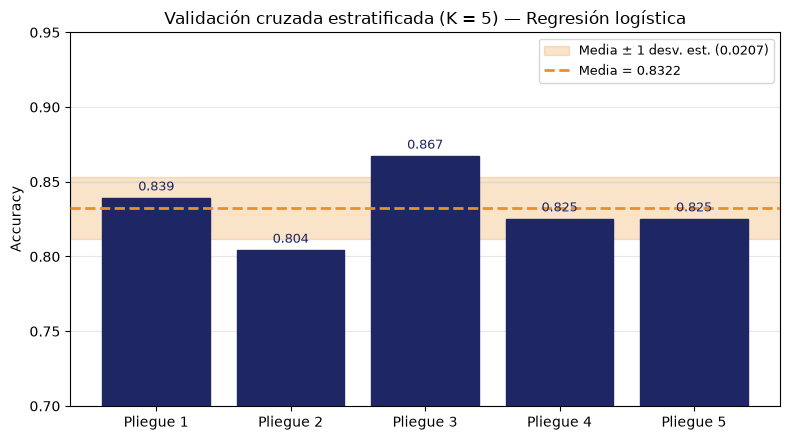

In [14]:
# ===== BLOQUE 16 — Gráfica: accuracy por pliegue (modelo ganador) =====
scores = scores_por_modelo['Regresión logística']
media, desv = scores.mean(), scores.std()
etiquetas = [f'Pliegue {i}' for i in range(1, len(scores) + 1)]

plt.figure(figsize=(8, 4.5))
plt.grid(axis='y', alpha=0.3, zorder=0)
plt.axhspan(media - desv, media + desv, color='#E8912B', alpha=0.25, zorder=1,
            label=f'Media ± 1 desv. est. ({desv:.4f})')
plt.bar(etiquetas, scores, color='#1E2664', edgecolor='#1E2664', zorder=3)
plt.axhline(media, color='#E8912B', linestyle='--', linewidth=2, zorder=4,
            label=f'Media = {media:.4f}')

for i, a in enumerate(scores):
    plt.text(i, a + 0.005, f'{a:.3f}', ha='center', fontsize=9, color='#1E2664', zorder=5)

plt.ylim(0.70, 0.95)
plt.ylabel('Accuracy')
plt.title('Validación cruzada estratificada (K = 5) — Regresión logística')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()